# Contact Mechanics (2D): Frictionless Rigid Platen

This notebook derives the simplest case of the contact boundary conditions implemented in Ratel, following

> Ratel documentation, *Contact Boundary Conditions* (`doc/modeling/material-models/boundary-conditions/contact.md`), which itself follows Mlika (2018), *Nitsche method for frictional contact and self-contact*.

## Scope of this notebook

Ratel's contact model supports large-deformation frictional contact against rigid platens or cylinders, with an optional augmented-Lagrangian outer loop. Deformable-deformable (mesh-to-mesh) contact is "in development".

For a first, step-by-step implementation we take the simplest corner of this framework:

- **Rigid flat platen** (a half-space with a fixed point $\boldsymbol c$ and fixed outward unit normal $\boldsymbol n_p$) rather than a cylinder or curved shape. A flat, non-rotating platen makes $\boldsymbol n_p$ **constant**, which removes essentially all of the shape-curvature linearization terms ($\mathrm{d} \boldsymbol n_y$, $\mathrm{d} \boldsymbol y$).
- **Frictionless** contact only (normal contact, Eq. `normal-contact` in Ratel's doc) — no tangential ball-projection operator, no slip velocity.
- **Linear elasticity** as the underlying material (`src/elasticity.jl`), not (yet) the Neo-Hookean or plasticity models, so the only new nonlinearity introduced is the contact condition itself.
- **Nitsche method with $\theta=0$**, matching Ratel's currently-implemented variant (simplest Jacobian), rather than the augmented-Lagrangian formulation.

## Why contact is different from every BC used so far

Every boundary condition implemented so far is either:
- **Dirichlet** (`bc_idx`/`u_bc`, prescribed displacement, fixed for the whole solve), or
- **Neumann/traction** (`ElasticityResidualNeumann`, a *fixed*, prescribed function of position, assembled once via `GetTractionGlobal` and reused unchanged across all Newton iterations).

Contact is neither: it is a **one-sided, state-dependent** condition. The body is free to separate from the platen ($g\ge 0$, no force) but cannot penetrate it ($g<0$ triggers a repulsive reaction). The reaction itself depends on the *current* trial displacement $u$, so unlike a prescribed traction, the contact face contribution to the residual (and Jacobian) must be **recomputed every Newton iteration**; closer in spirit to how `PlasticityResidual`/`PlasticityJacobian` recompute a state-dependent quantity (the return-mapped stress) at every iterate, than to the traction BC's one-time assembly.

## 1. Setup: rigid flat platen and the gap function

Let $\Gamma_c \subset \partial\Omega$ be the part of the body's boundary that may come into contact with a rigid platen. The platen is a half-space defined by a fixed point $\boldsymbol c$ and a fixed outward unit normal $\boldsymbol n_p$ (pointing away from the platen, into the region the body occupies). Because the platen is flat and does not translate or rotate within a load step, $\boldsymbol n_p$ is a **constant vector**, this is the key simplification relative to Ratel's general curved-shape treatment.

For a boundary point with reference (initial) position $\boldsymbol X$ and displacement $\boldsymbol u$, the current position is $\boldsymbol x = \boldsymbol X + \boldsymbol u$. The **signed gap** between the body and the platen is
$$
g(\boldsymbol u) = \boldsymbol n_p \cdot (\boldsymbol x - \boldsymbol c) = \boldsymbol n_p\cdot\boldsymbol u + \underbrace{\boldsymbol n_p\cdot(\boldsymbol X - \boldsymbol c)}_{g_0},
$$
where $g_0$ is the initial gap (geometry-only, computed once from the undeformed mesh). Since $\boldsymbol n_p$ is constant, $g$ is **exactly linear in $\boldsymbol u$**:
$$
\mathrm{d} g = \boldsymbol n_p \cdot \mathrm{d}\boldsymbol u
$$

Sign convention (matching Ratel): $g\ge 0$ means separated (no contact); $g<0$ means the body has penetrated the platen (physically disallowed, must be corrected by the contact reaction).

## 2. Contact traction and the Nitsche-penalized normal pressure

The scalar quantity that matters for frictionless normal contact is the **normal component of the Cauchy stress at the contact face, resolved along $\boldsymbol n_p$**:
$$
\sigma_n(\boldsymbol u) := \boldsymbol n_p \cdot \boldsymbol\sigma(\boldsymbol u) \cdot \boldsymbol n_p,
$$
using the linear-elasticity stress $\boldsymbol\sigma(\boldsymbol u) = \lambda\,\mathrm{tr}(\boldsymbol\varepsilon)\boldsymbol I + 2\mu\boldsymbol\varepsilon$, $\boldsymbol\varepsilon=\mathrm{sym}(\nabla\boldsymbol u)$, exactly as already implemented in `Compute_f1`/`src/elasticity.jl`. Note this double contraction $\boldsymbol n_p\otimes\boldsymbol n_p:\boldsymbol\sigma$ is unaffected by which direction is called "outward", it sidesteps the body-vs-platen outward-normal bookkeeping that appears in Ratel's more general $\boldsymbol\sigma_N=\boldsymbol P\cdot\hat{\boldsymbol N}$ derivation, which matters for curved/rotating shapes but is unnecessary here.

Standard continuum sign convention: **compressive** normal stress is **negative**, so physical contact requires $\sigma_n\le 0$ (matching Ratel's `normal-contact` conditions, Eq. `normal-contact`):
$$
g(\boldsymbol u)\ge 0, \qquad \sigma_n(\boldsymbol u)\le 0, \qquad \sigma_n(\boldsymbol u)\,g(\boldsymbol u) = 0.
$$
This is a classical KKT (complementarity) condition: non-smooth, and awkward to enforce directly inside a Newton solve.

**Nitsche regularization.** Following Ratel (Eq. `nitsche-normal-force`), define the Nitsche-penalized normal contact pressure
$$
\hat\sigma_n(\boldsymbol u) = \big[\, \sigma_n(\boldsymbol u) + \gamma\, g(\boldsymbol u) \,\big]_{\mathbb R^-} = \min\big(\sigma_n(\boldsymbol u)+\gamma g(\boldsymbol u),\ 0\big),
$$
where $\gamma>0$ is the Nitsche parameter (Ratel's rule of thumb: $\gamma\approx 200\,E$, $E$ = Young's modulus). Since $[\,\cdot\,]_{\mathbb R^-}$ projects onto the non-positive reals, $\hat\sigma_n\le 0$ always, the KKT complementarity is now built into a single smooth-almost-everywhere formula instead of an explicit if/else active-set test.

## 3. Weak form: which sign, and why

### Deriving the sign directly (virtual work)

Consider the reaction the platen exerts on the body once contact is active. This must be **repulsive**: when the body penetrates ($g<0$), the reaction pushes the body back in the $+\boldsymbol n_p$ direction (away from the platen, restoring $g\to 0$). A standard regularized (linear penalty) contact law makes this concrete: a repulsive pressure $p_N = k\langle -g\rangle \ge 0$ (active only when $g<0$) doing virtual work
$$
\delta W_{\text{contact}} = \int_{\Gamma_c} p_N\,(\boldsymbol v\cdot\boldsymbol n_p)\,dS
$$
on a virtual displacement $\boldsymbol v$. This is a *restoring/reaction* force — like an extra (state-dependent) stiffness — so it belongs on the **same side as the internal elastic virtual work**, i.e. it is **added**, not subtracted like an externally prescribed load:
$$
R(\boldsymbol u) = \int_\Omega \boldsymbol\sigma(\boldsymbol u):\nabla\boldsymbol v\,dV \;+\; \int_{\Gamma_c} p_N(\boldsymbol u)\,(\boldsymbol v\cdot\boldsymbol n_p)\,dS = 0.
$$

Replacing the crude linear penalty $p_N=k\langle -g\rangle$ with Ratel's Nitsche-regularized pressure ($-\hat\sigma_n\ge 0$ plays the role of $p_N$, since $\hat\sigma_n\le0$) gives the frictionless, $\theta=0$ contact weak form:
$$
\boxed{\,R(\boldsymbol u) = \int_\Omega \boldsymbol\sigma(\boldsymbol u):\nabla\boldsymbol v\,dV \;+\; \int_{\Gamma_c} \hat\sigma_n(\boldsymbol u)\,(\boldsymbol v\cdot\boldsymbol n_p)\,dS = 0.\,}
$$

**Sanity check.** Near the start of a load step where the elastic self-stress is small ($\sigma_n\approx 0$) and the body has just penetrated ($g<0$), $\hat\sigma_n\approx\gamma g<0$. Solving $R=0$ then requires $\int\boldsymbol\sigma:\nabla\boldsymbol v\,dV = -\int(\boldsymbol v\cdot\boldsymbol n_p)\hat\sigma_n\,dS = \int(\boldsymbol v\cdot\boldsymbol n_p)\,\gamma|g|\,dS > 0$ for $\boldsymbol v$ along $+\boldsymbol n_p$ i.e. the internal elastic response must supply a **positive, repulsive** force pushing the body back out along $+\boldsymbol n_p$. This is exactly the physically correct non-penetration behavior.

### A deliberate deviation from `ElasticityResidualNeumann`

This project's existing `src/elasticity.jl` code has **two different local sign conventions** already coexisting: the volume/body-force term (`Compute_f0`) bakes its minus sign in and is **added** (`ve = Bu.B'*f0 + Bu.D'*f1`), matching Ratel; but `ElasticityResidualNeumann` **subtracts** a separately-assembled prescribed traction load (`v .-= Ft`), because that function's `Ft` is defined as the *positive-signed applied traction*, and subtracting it reproduces the usual $Ku=F$ equilibrium form.

Contact must **not** reuse the traction-subtracting pattern: `Ft_contact := ∫ Bu' hat_σ_n n_p dS` needs to be **added**, exactly like the body-force term, since $\hat\sigma_n$ (unlike a prescribed traction) already carries the correct sign as a *reaction*, not an applied load.

## 4. Newton linearization

Because the platen is flat and non-rotating, $\boldsymbol n_p$ is constant, so $\mathrm{d}\boldsymbol n_p = 0$, this eliminates essentially all of the shape-curvature linearization (their $\mathrm{d}\boldsymbol y$, $\mathrm{d}\boldsymbol n_y$ terms, needed for curved/cylindrical shapes). What remains is very simple:

$$
\mathrm{d} g = \boldsymbol n_p\cdot\mathrm{d}\boldsymbol u,
$$
$$
\mathrm{d}\sigma_n = \boldsymbol n_p\cdot\mathrm{d}\boldsymbol\sigma\cdot\boldsymbol n_p, \qquad \mathrm{d}\boldsymbol\sigma = \lambda\,\mathrm{tr}(\nabla\mathrm{d}\boldsymbol u)\,\boldsymbol I + 2\mu\,\mathrm{sym}(\nabla\mathrm{d}\boldsymbol u)
$$
(exactly the existing linear-elasticity tangent already computed by `Compute_df1`).

The Nitsche pressure $\hat\sigma_n=\min(\sigma_n+\gamma g,\ 0)$ is a $\min$ of a smooth function against $0$: not classically differentiable exactly where $\sigma_n+\gamma g=0$, but **semismooth**, with a well-defined generalized (Clarke) derivative almost everywhere. Following Ratel (Eq. `linearized-frictionless-contact`), using the Heaviside function $H$,
$$
\mathrm{d}\hat\sigma_n = H\big(-(\sigma_n+\gamma g)\big)\cdot\big(\mathrm{d}\sigma_n + \gamma\,\mathrm{d} g\big),
$$
i.e. the tangent is **switched on** ($H=1$) wherever the quadrature point is currently in the active (contact) branch ($\sigma_n+\gamma g\le 0$), and **off** ($H=0$) where it is separated. This is the "semismooth Newton" method standard for Nitsche/penalty contact: at the exact switching point the derivative is ambiguous, but Newton only needs *a* generalized derivative to converge, not continuity of the Hessian.

Putting it together, the contact contribution to the Jacobian-vector product is
$$
\mathrm{d} R_{\text{contact}}(\boldsymbol v,\mathrm{d}\boldsymbol u) = \int_{\Gamma_c} (\boldsymbol v\cdot\boldsymbol n_p)\; H\big(-(\sigma_n+\gamma g)\big)\,\big(\boldsymbol n_p\cdot\mathrm{d}\boldsymbol\sigma\cdot\boldsymbol n_p + \gamma\,\boldsymbol n_p\cdot\mathrm{d}\boldsymbol u\big)\,dS.
$$

Two useful limiting checks for later testing: as $\gamma\to\infty$ this tangent term dominates and approaches a Dirichlet-like penalty (rigid non-penetration); at any quadrature point where $H=0$ throughout a load step (never in contact), both the residual and Jacobian contact contributions vanish identically, exactly reproducing plain `ElasticityResidual`/`ElasticityJacobian`.

## 5. Discretization plan

- **Face restriction.** Reuse the existing `FEFaceIndices`/`GetFaceQdata` machinery from `mesh.jl` (already built for traction BCs) to identify $\Gamma_c$ and its face quadrature points, the contact face is geometrically identified the same way a traction face is, just given to a different residual/Jacobian assembly routine.
- **Per-iteration recomputation.** Unlike `GetTractionGlobal` (assembled once, reused every Newton iteration), the contact face residual and Jacobian must be recomputed at **every** Newton iterate, since $g$, $\sigma_n$, and the active-set indicator $H$ all depend on the current trial $\boldsymbol u$. This mirrors how `PlasticityResidual`/`PlasticityJacobian` recompute the (state-dependent) return-mapped stress every iteration, rather than the one-shot `GetTractionGlobal` pattern.
- **No new history state.** Unlike plasticity, contact needs no persisted state between load steps — $g(\boldsymbol u)$, $\sigma_n(\boldsymbol u)$, and $H$ are all pure functions of the *current* trial displacement, recomputed fresh each iteration. (This changes once friction and its slip-velocity history are added later.)
- **Jacobian assembly.** Add a `ContactResidualJacobian`-style contribution on top of `ElasticityJacobian`, computed via the same finite-basis-direction loop already used in `Compute_df1`'s caller, gated by the Heaviside indicator per quadrature point.
- **Parameter choice.** Start with Ratel's rule of thumb $\gamma \approx 200\,E$ (Young's modulus $E$ derived from the same $\lambda,\mu$ already used elsewhere), and check sensitivity — too small under-penalizes penetration, too large can slow Newton convergence per Ratel's own note.
- **Verification plan for the `.jl` file**: (1) an FD-check of the semismooth Jacobian *away* from the active-set switching points (where it is classically differentiable); (2) a patch/limit test — a body resting exactly on the platen ($g_0=0$) under a small uniform pressure should reproduce a simple 1D compression solution; (3) a partial-contact demo (body tilted or off-center loaded) to show the method correctly resolves a *subset* of $\Gamma_c$ as active, which a Dirichlet constraint could never do.

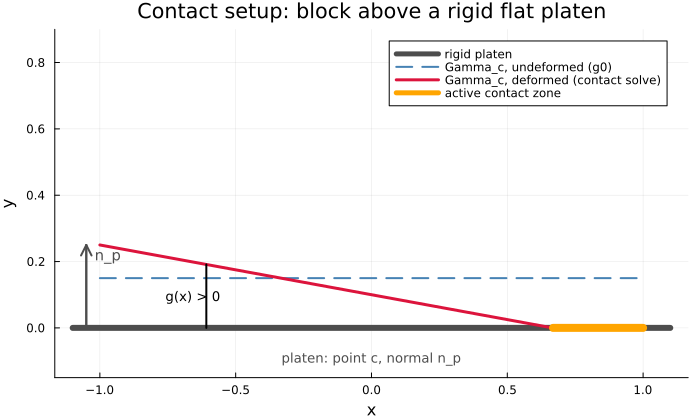

In [1]:
using Plots

# Schematic of the contact setup: a 2D block above a flat rigid platen,
# showing the gap g, the platen normal n_p, and the contact zone Gamma_c.
# Purely illustrative (no FE solve yet) -- fixes notation before writing code.

platen_y = 0.0
xs = range(-1.0, 1.0, length = 200)

# Undeformed bottom face: a small uniform initial gap g0 > 0 everywhere.
bottom_undeformed = fill(0.15, length(xs))

# A plausible deformed bottom face under a downward, off-center load: the
# block tilts, touching the platen over part of Gamma_c (active contact
# zone) while the rest remains separated (g > 0) -- exactly the kind of
# PARTIAL contact a Dirichlet constraint could never resolve.
tilt_line = @. 0.10 - 0.15 * xs
bottom_deformed = max.(platen_y, tilt_line)

plt = plot(size = (700, 420), legend = :topright, xlabel = "x", ylabel = "y",
    title = "Contact setup: block above a rigid flat platen", ylims = (-0.15, 0.9))

# Platen (rigid, flat)
plot!(plt, [-1.1, 1.1], [platen_y, platen_y], lw = 6, color = :gray30, label = "rigid platen")
annotate!(plt, 0.0, -0.09, text("platen: point c, normal n_p", 9, :gray30))

# Platen normal arrow n_p
quiver!(plt, [-1.05], [platen_y], quiver = ([0.0], [0.25]), color = :gray30, lw = 2, label = false)
annotate!(plt, -0.97, 0.22, text("n_p", 10, :gray30))

# Undeformed contact face (reference position of Gamma_c)
plot!(plt, xs, bottom_undeformed, lw = 2, ls = :dash, color = :steelblue,
    label = "Gamma_c, undeformed (g0)")

# Deformed contact face (current position, after a downward off-center load)
plot!(plt, xs, bottom_deformed, lw = 3, color = :crimson, label = "Gamma_c, deformed (contact solve)")

# Highlight the active contact zone: where the deformed face touches the platen
touching = tilt_line .<= platen_y + 1e-9
if any(touching)
    xt = xs[touching]
    plot!(plt, xt, fill(platen_y, length(xt)), lw = 8, color = :orange, label = "active contact zone")
end

# A representative gap arrow g(x) at a point that remains separated
i0 = 40
plot!(plt, [xs[i0], xs[i0]], [platen_y, bottom_deformed[i0]], lw = 2, color = :black, label = false)
annotate!(plt, xs[i0] - 0.05, (platen_y + bottom_deformed[i0]) / 2, text("g(x) > 0", 9, :black))

plt


## 6. The face basis: why the existing traction machinery isn't enough

Every earlier boundary condition in this package (`FEFaceIndices`, `GetFaceQdata`, `GetTractionGlobal`) only ever needs the face's own **physical position** (to evaluate a prescribed function `t(x,y)`, or to compute the arc length `ds` for integration). That's built from just the **2 corner nodes** of the face, interpolated linearly (`febasis1D(2, ...)`)  -- geometry only, no field values or gradients involved.

Contact needs something genuinely different: `hat_sigma_n` depends on the **Cauchy stress** at the face, i.e. on `grad_u`, the displacement field's *gradient* there -- not just its value, and not just the face geometry. A gradient depends on *all* `P^2` shape functions of the element it's evaluated in, not only the `P` of them that happen to sit exactly on that edge. So we need a basis that:

1. reuses the **same `P`-node volumetric shape functions** as the interior residual (not a separate, lower-order "face element"), so the gradient it produces is the true element gradient, and
2. is **tabulated** (interpolated/differentiated) only at the `Q` quadrature points that lie on one edge of the reference element, by fixing the perpendicular reference coordinate at its boundary value (`xi=-1` or `xi=+1`, via `feval1D_at`) while the tangential coordinate runs over the normal `Q`-point rule.

That's exactly what `febasis2D_face`/`FEFaceBasis` build (`src/basis.jl`), and `GetQdataFace` (`src/mesh.jl`) is the matching geometry piece: the *same* trick applied to the `P=2` geometry basis, so the full `2x2` Jacobian (needed to push the reference-space gradient into a physical one, exactly like `dXdx_T` does for the interior) is available at those same face points -- using the element's **full 4 corners**, not just the 2 corners `GetFaceQdata` uses for arc length. The residual/Jacobian assembly then uses the **full element restriction** `Ind.Er_u[e]` (all `P^2` local dofs), not the face-only `Fx.Er_face_u` used for traction.

### The Ratel equivalent

The volume-vs-boundary distinction lives entirely in *which* tabulation and *which* element-restriction you build. Ratel builds exactly two flavors, and contact needs both together:

| Purpose | Ratel | This package |
|---|---|---|
| Face-only geometry (position, arc length/area) -- what a *prescribed* traction/pressure BC needs | `RatelDMPlexCeedBasisCreate(height=PLEXHEIGHT_FACE)`: a genuine `(d-1)`-dimensional `PetscFE` "height subspace", own quadrature | `GetFaceQdata` (already existed, 2-corner linear geometry) |
| Face-restricted dofs, values only | `CeedElemRestriction` with `height=PLEXHEIGHT_FACE` | `FEFaceIndices`/`Fx.Er_face_u` |
| **Volume field's gradient at face points** what contact (or any stress-dependent boundary term) needs | `RatelDMPlexCeedBasisCellToFaceCreate`: the **same full `P`-node volumetric `PetscFE`**, tabulated via `PetscFEGetFaceTabulation` at quadrature points collapsed onto one reference face | `febasis2D_face`/`FEFaceBasis` |
| Element restriction pulling in the **whole cell's** dofs (not just the face's), paired with the basis above | `RatelDMPlexCeedElemRestrictionCreate(height=PLEXHEIGHT_CELL)`, fed a *face* domain label. PETSc returns the parent **cell's** full dof offsets | `Ind.Er_u[e]` (looped only over `Fx.elems`) |
| Geometry Jacobian for pushing the reference gradient to a physical one, at face points | `basis_x_cell_to_face` (built the same "cell-to-face" way, for the coordinate field) | `GetQdataFace` |

This is the exact mechanism behind Ratel's real Nitsche contact implementation (`RatelBoundaryContactNitscheSetupMaterialSuboperators`).

**One real difference.** Ratel gets this via `PetscFEGetFaceTabulation`, a *general* PETSc utility that works for any element topology (tets, hexes, prisms, arbitrary order) because PETSc's `FE` abstraction already knows how to tabulate itself at arbitrary points. We don't have that generic machinery here, so `febasis2D_face` builds the same result by hand from the tensor-product structure directly: `kron(Bpt, B1)` etc., collapsing one of the two Kronecker factors to a single boundary-point evaluation instead of the normal `Q`-point rule. It only works because our elements are strictly tensor-product quads. Ratel's general unstructured-mesh version has to handle simplices too, which is exactly why it needs the heavier PETSc `FE` machinery instead of a Kronecker-product shortcut.

## Demo: a block tipping onto a rigid platen (partial contact)

We now run the actual solver (`src/contact.jl`) instead of the hand-sketched schematic above. To make partial contact happen for real, the setup is deliberately asymmetric: a downward traction is applied to only the **left 40%** of the top edge, everything else on top/left/right is left natural (free), and the bottom edge sits exactly on a rigid platen (`g0=0`) governed by `ContactResidual`/`ContactJacobian`.

Frictionless contact only resists the *normal* (here, vertical) direction — nothing here resists horizontal rigid-body translation, since both the applied traction and the contact reaction are purely vertical. Left entirely unconstrained, the tangent stiffness would be singular. We fix this the minimal way: pin the **x-displacement only** at a single bottom node, leaving contact fully in charge of the vertical direction everywhere (including at that node).

In [2]:
using FESolid2D
using LinearAlgebra
using NLsolve
using Plots

default(linewidth=2)

P, Q, num_comp, Qmode = 2, 2, 2, "GAUSS"
Bx = FEBasis(2, Q, 2, Qmode)
Bu = FEBasis(P, Q, num_comp, Qmode)

nx, ny, aspect_ratio = 12, 6, 2   # domain: x in [0,1], y in [0, 1/aspect_ratio]
xc, yc = GetCoordMesh("uniform", nx, ny, aspect_ratio)
Ind = FEIndices(P, num_comp, nx, ny)
num_nodes = maximum(Ind.idx_u)

lambda, mu = 1.0, 1.0
E = mu * (3lambda + 2mu) / (lambda + mu)

# Contact: rigid flat platen at y=0 (g0=0, touching), Ratel's gamma ~ 200E rule of thumb
side = "bottom"
Fx_c = FEFaceIndices(P, num_comp, nx, ny, Ind, side)
FaceBu = febasis2D_face(P, Q, num_comp, Qmode, side)
FaceBx = febasis2D_face(2, Q, 2, Qmode, side)
cp = ContactParams([0.0, 1.0], [0.0, 0.0], 200 * E)

# Off-center downward traction: only on the left 40% of the top edge
Fx_t = FEFaceIndices(P, num_comp, nx, ny, Ind, "top")
t0 = 0.06
t_top(x, y) = vcat(zeros(length(x)), [xi < 0.4 ? -t0 : 0.0 for xi in x])
Ft_full = GetTractionGlobal(xc, yc, Fx_t, Ind, Bu, t_top)

# Pin x-displacement at a single bottom node (removes the otherwise-unconstrained
# horizontal rigid-body mode); y is left to contact everywhere on the bottom.
bc_idx = [Ind.idx_b[1]]
u_bc = [0.0]

f_zero(lambda, mu, x, y) = zeros(2 * length(x)) # no body force
u_dof = num_comp * num_nodes;

## Load-stepping Newton solve

Same load-stepping pattern as the plasticity/hyperelasticity notebooks, but with the traction combined by hand with `ContactResidual`/`ContactJacobian` (contact has no `...Neumann` convenience wrapper yet, since it's the only model needing *both* a prescribed traction *and* a state-dependent face contribution at once).

In [3]:
function contact_residual_with_traction(uu, Ft)
    v = ContactResidual(lambda, mu, cp, uu, xc, yc, Ind, Bx, Bu, FaceBu, FaceBx, Fx_c, f_zero, bc_idx, u_bc)
    v .-= vec(Ft)
    v[bc_idx] = uu[bc_idx] - u_bc
    return v
end

nsteps = 6
u = zeros(u_dof)
for s = 1:nsteps
    frac = s / nsteps
    Ft = frac .* Ft_full
    result = nlsolve(
        uu -> contact_residual_with_traction(uu, Ft),
        uu -> ContactJacobian(lambda, mu, cp, uu, xc, yc, Ind, Bx, Bu, FaceBu, FaceBx, Fx_c, bc_idx),
        u; method=:newton)
    @assert result.f_converged "step $s did not converge"
    global u = result.zero
end

uy_bottom = u[num_nodes+1:end][Ind.idx_b]
println("min uy at bottom (penetration, should be ~0 or slightly negative): ", minimum(uy_bottom))
println("max uy at bottom (separation on the unloaded side): ", maximum(uy_bottom))

min uy at bottom (penetration, should be ~0 or slightly negative): -6.302087625139697e-6
max uy at bottom (separation on the unloaded side): 0.004856503583274682


## Visualize: undeformed vs. deformed mesh

The left (loaded) side stays pinned to the platen; the right (unloaded) side lifts off as the block tips — genuine **partial** contact, resolved by the solver rather than assumed.

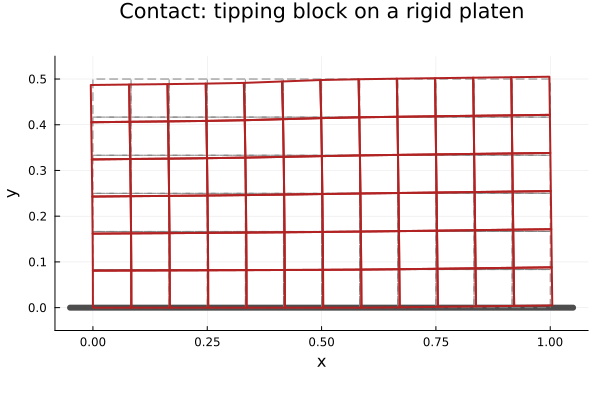

In [4]:
xdef = xc .+ u[1:num_nodes]
ydef = yc .+ u[num_nodes+1:end]

function plot_mesh!(p, x, y, idx_x; kwargs...)
    order = [1, 2, 4, 3, 1]
    for e in 1:size(idx_x, 2)
        plot!(p, x[idx_x[order, e]], y[idx_x[order, e]]; legend=false, kwargs...)
    end
    return p
end

p1 = plot(aspect_ratio=:equal, xlabel="x", ylabel="y",
    title="Contact: tipping block on a rigid platen", ylims=(-0.05, 0.55))
plot!(p1, [-0.05, 1.05], [0.0, 0.0], lw=6, color=:gray30, label=false) # platen
plot_mesh!(p1, xc, yc, Ind.idx_x, color=:gray, linestyle=:dash, linewidth=1)
plot_mesh!(p1, xdef, ydef, Ind.idx_x, color=:firebrick, linewidth=2)
p1

## Contact pressure distribution

`ContactFaceLocalHatSigma` gives `hat_sigma_n <= 0` at every face quadrature point; we plot `-hat_sigma_n >= 0` as the physical contact pressure. It should be largest under the applied load, decay smoothly through the transition, and drop to exactly zero once the gap opens — with no sharp jump, since the Nitsche projection is continuous (only its *derivative* is discontinuous, at the active-set boundary).

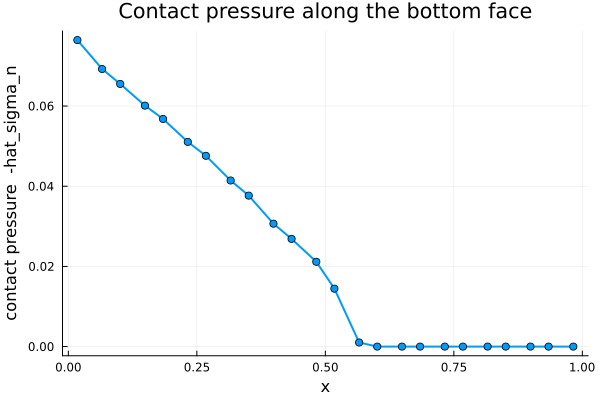

In [5]:
function contact_pressure_profile(cp, lambda, mu, u, xc, yc, Ind, FaceBu, FaceBx, Fx)
    xs, ps = Float64[], Float64[]
    for k in eachindex(Fx.elems)
        e = Fx.elems[k]
        Coord_E = GetCoordElem(xc, yc, Ind.Er_x, e)
        dXdx_T_face = GetQdataFace(Coord_E, FaceBx)
        Coord_face = Fx.Er_face_x[k] * [xc; yc]
        xq, yq, _ = GetFaceQdata(Coord_face, FaceBu.Q, FaceBu.Qmode)
        g0 = GapFunction0(cp, xq, yq)
        ue = Ind.Er_u[e] * u
        hat_sigma_n = ContactFaceLocalHatSigma(cp, lambda, mu, ue, dXdx_T_face, g0, FaceBu)
        append!(xs, xq)
        append!(ps, -hat_sigma_n) # report as a positive pressure
    end
    order = sortperm(xs)
    return xs[order], ps[order]
end

xs, ps = contact_pressure_profile(cp, lambda, mu, u, xc, yc, Ind, FaceBu, FaceBx, Fx_c)
p2 = plot(xs, ps, marker=:circle, xlabel="x", ylabel="contact pressure  -hat_sigma_n",
    title="Contact pressure along the bottom face", legend=false)